In [1]:
# ANN (Artificial Neural Network) or MLP (Multi-Layered Perceptron)
# Kaggle MNISTworkdir/datasets/fashion-MNIST/
!ls workdir/datasets/fashion-MNIST/

# It contains images of size 28*28.  

fashion-mnist_test.csv	 t10k-images-idx3-ubyte  train-images-idx3-ubyte
fashion-mnist_train.csv  t10k-labels-idx1-ubyte  train-labels-idx1-ubyte


In [2]:
# Workflow
# - Dataloader
# - Training (784 * 128 * 64 * 10)
# - Evaluation

In [3]:
# Load Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [4]:
# Set Manual Seed for Reproducability
torch.manual_seed(42)

In [5]:
# Load Dataset
train = pd.read_csv("./workdir/datasets/fashion-MNIST/fashion-mnist_train.csv")
test = pd.read_csv("./workdir/datasets/fashion-MNIST/fashion-mnist_test.csv")

print(train.shape, test.shape)

(60000, 785) (10000, 785)


In [6]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


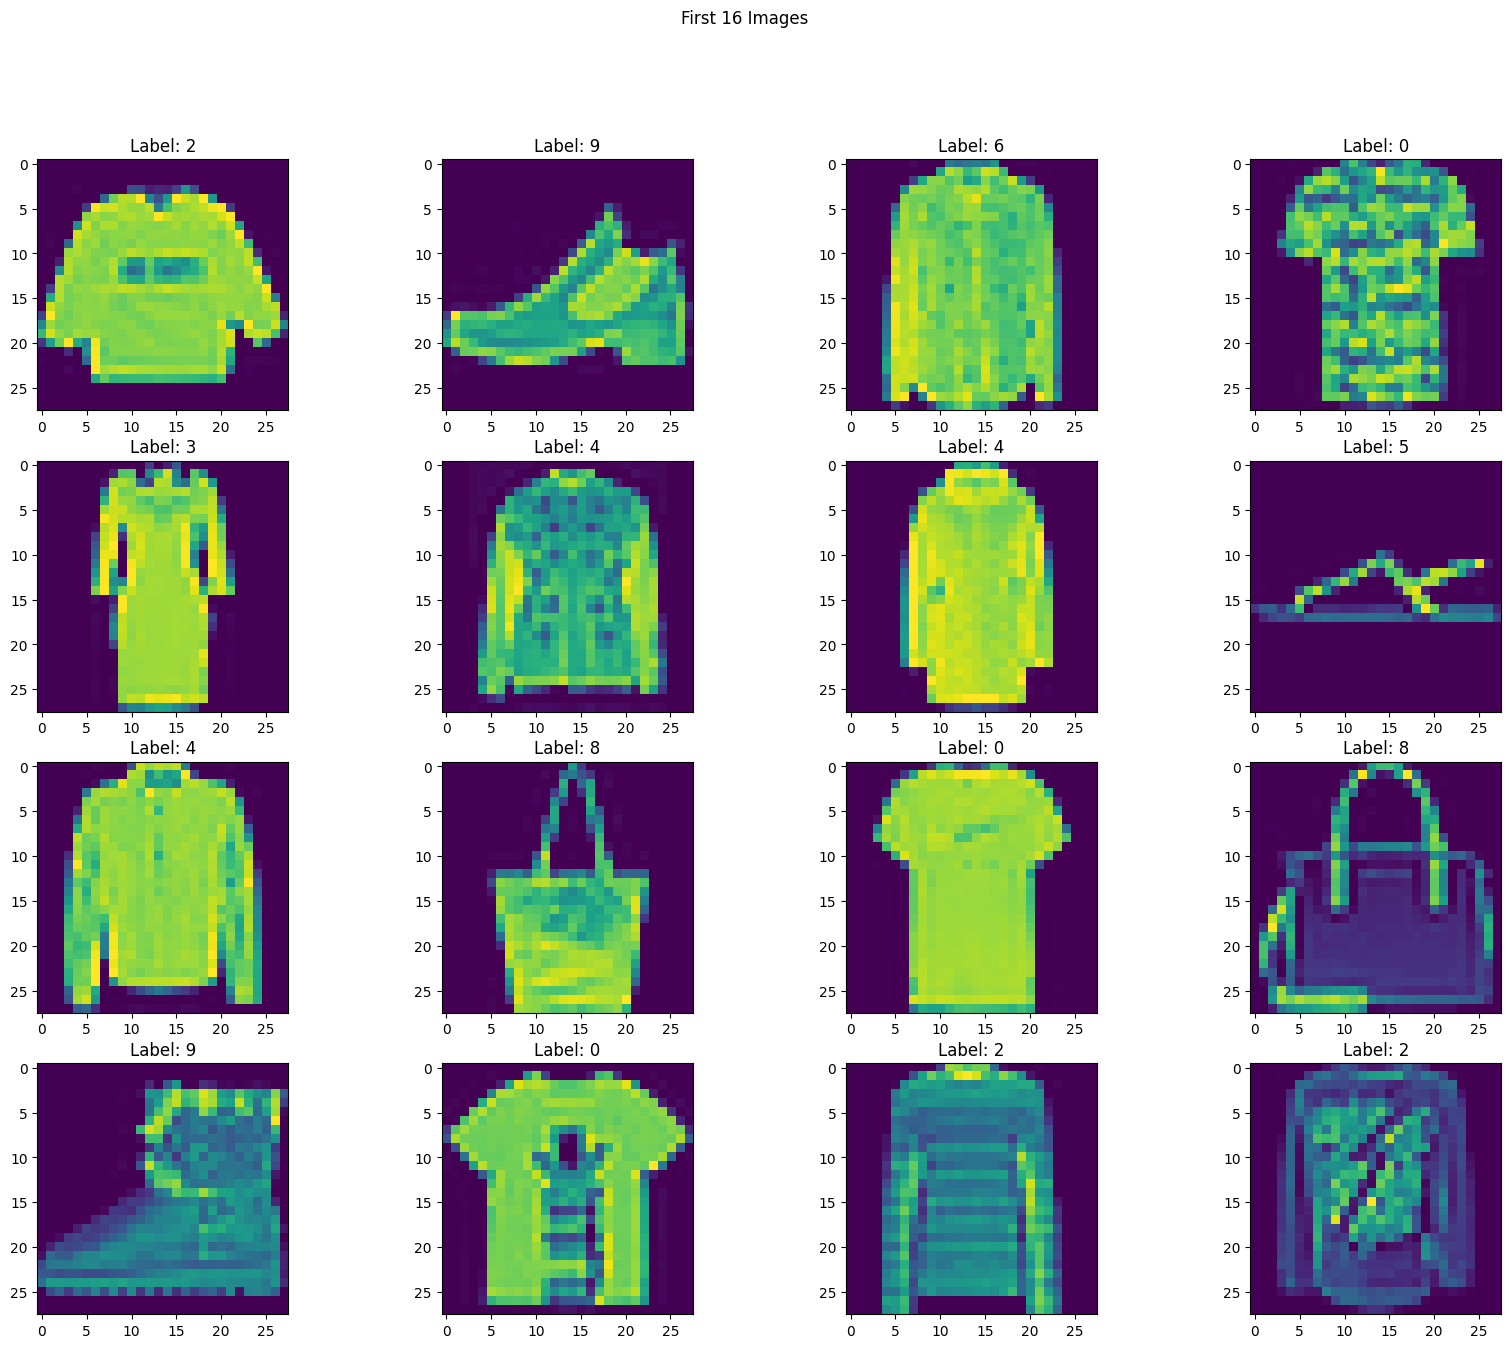

In [8]:
# Create a 4x4 grid of Images (Plot Samples)
fig, axes = plt.subplots(4,4, figsize=(20, 15))
fig.suptitle("First 16 Images")
axes = axes.flatten()

for i in range(16):
    img = train.iloc[i, 1:].values.reshape(28, 28)
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {train.iloc[i, 0]}")

In [9]:
# Creating X_train, y_train, X_test, y_test
X_train = train.drop("label", axis=1).values
X_test = test.drop("label", axis=1).values
y_train = train["label"].values
y_test = test["label"].values

In [10]:
# Scaling the features
X_train = X_train / 255.0
X_test = X_test / 255.0

In [11]:
# Create CustomDataset Class
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [12]:
# Create Train Dataset 
train_dataset = CustomDataset(X_train, y_train)

In [13]:
# Create Test Dataset
test_dataset = CustomDataset(X_test, y_test)

In [14]:
len(train_dataset), len(test_dataset)

(60000, 10000)

In [15]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0157, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.2431, 0.2392, 0.0824, 0.1137, 0.0902,
         0.2000, 0.5333, 0.2392, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [16]:
test_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0353, 0.0314,
         0.0000, 0.0000, 0.1333, 0.1137, 0.0275, 0.0000, 0.0431, 0.0941, 0.0000,
         0.0000, 0.0118, 0.0118, 0.0039, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0157, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.1725, 0.3451, 0.3882, 0.4784, 0.4824, 0.3137,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0039, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.0000,
         0.0118, 0.1804, 0.6824, 0.9765, 0.2627, 0.0000, 0.3686, 0.8235, 0.2392,
         0.0549, 0.8314, 0.6157, 0.1451, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0078, 0.0078, 0.0000, 0.0902,
         0.6588, 0.8078, 0.9490, 0.9373, 0.9333, 0.8392, 0.4902, 0.2392, 0.4431,
         0.2902, 0.5216, 0.9255, 0.9333, 0.9255, 0.7961, 0.7216, 0.0784, 0.0000,
         0.0039, 0.0000, 0.0

In [17]:
# Create Train and Test DataLoader

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [18]:
# Define NN Class

class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, X):
        return self.layers(X)

In [19]:
# Define Hyperparameters
learning_rate = 0.1 
epochs = 100

# Instantiate Model
model = MyNN(X_train.shape[1])
if torch.cuda.is_available():
    print(f"Using Device: {torch.cuda.get_device_name()}")
    device = torch.device("cuda")
else:
    cpu = !lscpu | grep 'Model name'
    cpu = cpu[0][12:].strip()
    print(f"Using Device: {cpu}")
    device = torch.device("cpu")

model = model.to(device = device)

# Loss Function
loss_function = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:
        # Copy Batch Features and Batch Labels to GPU
        batch_features, batch_labels = batch_features.to(device=device), batch_labels.to(device=device)
        # Forward Pass
        outputs = model(batch_features)
        # Compute Loss
        loss = loss_function(outputs, batch_labels)
        # Zero Parameter Gradients
        optimizer.zero_grad()
        # Backpropagation
        loss.backward()
        # Update Gradients
        optimizer.step()
        # Update total_epoch_loss
        total_epoch_loss += loss.item()
    print(f"Epoch: {epoch+1}, Average Epoch Loss: {total_epoch_loss/len(train_loader)}")

Using Device: NVIDIA GeForce RTX 5070
Epoch: 1, Average Epoch Loss: 0.6009204726934433
Epoch: 2, Average Epoch Loss: 0.4137798417051633
Epoch: 3, Average Epoch Loss: 0.37154633285800615
Epoch: 4, Average Epoch Loss: 0.3445488834619522
Epoch: 5, Average Epoch Loss: 0.3253527345776558
Epoch: 6, Average Epoch Loss: 0.30824146071473757
Epoch: 7, Average Epoch Loss: 0.29631610575119655
Epoch: 8, Average Epoch Loss: 0.28549083634614947
Epoch: 9, Average Epoch Loss: 0.27393676901857056
Epoch: 10, Average Epoch Loss: 0.26609293766617775
Epoch: 11, Average Epoch Loss: 0.2584754081487656
Epoch: 12, Average Epoch Loss: 0.2514889467835426
Epoch: 13, Average Epoch Loss: 0.2439056351552407
Epoch: 14, Average Epoch Loss: 0.23558057339837155
Epoch: 15, Average Epoch Loss: 0.23151258221566678
Epoch: 16, Average Epoch Loss: 0.2265845296283563
Epoch: 17, Average Epoch Loss: 0.21974550949136415
Epoch: 18, Average Epoch Loss: 0.2151814214696487
Epoch: 19, Average Epoch Loss: 0.21076822625796
Epoch: 20, Ave

In [20]:
# Evaluation
# Set Model to Eval Mode: Some features perform differently in training and prediction, so setting the model to Eval mode is necessary
model.eval()

# Evaluation Loop
total = 0
correct = 0
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        # Copy Batch Features and Batch Labels to GPU
        batch_features, batch_labels = batch_features.to(device=device), batch_labels.to(device=device)
        # Forward Pass 
        outputs = model(batch_features) # -> This will give us a probaility per class. (Tensor of 10 values.) We have to extract labels from this.
        _, predicted = torch.max(outputs, 1)

        # Update Total
        total += batch_labels.shape[0]

        # Update Correct
        correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.8829


In [22]:
# Evaluation on Train Dataset (How well it has fit the data.)
model.eval()

# Evaluation Loop
total = 0
correct = 0
with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        # Copy Batch Features and Batch Labels to GPU
        batch_features, batch_labels = batch_features.to(device=device), batch_labels.to(device=device)
        # Forward Pass 
        outputs = model(batch_features) # -> This will give us a probaility per class. (Tensor of 10 values.) We have to extract labels from this.
        _, predicted = torch.max(outputs, 1)

        # Update Total
        total += batch_labels.shape[0]

        # Update Correct
        correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(f"Train Accuracy: {accuracy}")

Train Accuracy: 0.9672333333333333


In [ ]:
# The Model is overfitting as train accuracy is amost 10% higher than the test accuracy.

In [21]:
# How to improve accuracy:
# Can use other Optimizers, can use different learning rates, can vary epochs, 
# can try different weight initialization techniques, can use regularization, can use dropout, 
# can use batch normalization, can change model architecture. 

In [ ]:
# We need to reduce the Overfitting.
# What are the different ways to reduce it. 
# 1. Adding more data. 
# 2. Reducing the complexity of NN architecture.
# 3. Regularization (Watch Video)
# 4. Dropouts (Watch Video)
# 5. Data Augumentation
# 6. Batch Normalization (Watch Video)
# 7. Early Stopping


# We are going to apply 3, 4 and 6 as these are applicable in our case.

In [24]:
# Dropout
# Applied to Hidden Layers
# Applied after ReLU Activation Function
# Randomly turns off p% of neurons in the hidden layer during each forward pass.
# This as Regularization effect.
# During Evaluation Dropout is not used.

In [26]:
# Updated Model Class
class MyNN_U1(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.BatchNorm1d(128), # Batch Normalization (Before Activation Function)
            nn.ReLU(),
            nn.Dropout(p=0.3), # Dropout (After Activation function)
            nn.Linear(128, 64),
            nn.BatchNorm1d(64), # Batch Normalization (Before Activation Function)
            nn.ReLU(),
            nn.Dropout(p=0.3), # Dropout (After Activation function)
            nn.Linear(64, 10)
        )
    
    def forward(self, X):
        return self.layers(X)

In [27]:
# Define Hyperparameters
learning_rate = 0.1 
epochs = 100

# Instantiate Model
model = MyNN_U1(X_train.shape[1])
if torch.cuda.is_available():
    print(f"Using Device: {torch.cuda.get_device_name()}")
    device = torch.device("cuda")
else:
    cpu = !lscpu | grep 'Model name'
    cpu = cpu[0][12:].strip()
    print(f"Using Device: {cpu}")
    device = torch.device("cpu")

model = model.to(device = device)

# Loss Function
loss_function = nn.CrossEntropyLoss()

# Optimizer (With L2 Regularization)
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# Training Loop
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:
        # Copy Batch Features and Batch Labels to GPU
        batch_features, batch_labels = batch_features.to(device=device), batch_labels.to(device=device)
        # Forward Pass
        outputs = model(batch_features)
        # Compute Loss
        loss = loss_function(outputs, batch_labels)
        # Zero Parameter Gradients
        optimizer.zero_grad()
        # Backpropagation
        loss.backward()
        # Update Gradients
        optimizer.step()
        # Update total_epoch_loss
        total_epoch_loss += loss.item()
    print(f"Epoch: {epoch+1}, Average Epoch Loss: {total_epoch_loss/len(train_loader)}")

Using Device: NVIDIA GeForce RTX 5070
Epoch: 1, Average Epoch Loss: 0.6042001898129781
Epoch: 2, Average Epoch Loss: 0.4796167537768682
Epoch: 3, Average Epoch Loss: 0.4445068345864614
Epoch: 4, Average Epoch Loss: 0.42215614796479545
Epoch: 5, Average Epoch Loss: 0.40570080272754033
Epoch: 6, Average Epoch Loss: 0.3923808897972107
Epoch: 7, Average Epoch Loss: 0.3839154406706492
Epoch: 8, Average Epoch Loss: 0.3764492271145185
Epoch: 9, Average Epoch Loss: 0.3690054267803828
Epoch: 10, Average Epoch Loss: 0.36421851781606673
Epoch: 11, Average Epoch Loss: 0.35922656890153887
Epoch: 12, Average Epoch Loss: 0.35362424489855765
Epoch: 13, Average Epoch Loss: 0.34585274745623273
Epoch: 14, Average Epoch Loss: 0.3453232021172841
Epoch: 15, Average Epoch Loss: 0.34445093700091045
Epoch: 16, Average Epoch Loss: 0.34266320148706436
Epoch: 17, Average Epoch Loss: 0.334997253437837
Epoch: 18, Average Epoch Loss: 0.33318432817459104
Epoch: 19, Average Epoch Loss: 0.32948693582614264
Epoch: 20, A

In [28]:
# Evaluation
# Set Model to Eval Mode: Some features perform differently in training and prediction, so setting the model to Eval mode is necessary. 
# (See in this case Dropout & Batch Normalization are not working during Eval Mode.)
model.eval()

MyNN_U1(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [29]:
# Evaluation Loop (Test Data)
total = 0
correct = 0
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        # Copy Batch Features and Batch Labels to GPU
        batch_features, batch_labels = batch_features.to(device=device), batch_labels.to(device=device)
        # Forward Pass 
        outputs = model(batch_features) # -> This will give us a probaility per class. (Tensor of 10 values.) We have to extract labels from this.
        _, predicted = torch.max(outputs, 1)

        # Update Total
        total += batch_labels.shape[0]

        # Update Correct
        correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.8951


In [30]:
# Evaluation on Train Dataset (How well it has fit the data.)
model.eval()

# Evaluation Loop
total = 0
correct = 0
with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        # Copy Batch Features and Batch Labels to GPU
        batch_features, batch_labels = batch_features.to(device=device), batch_labels.to(device=device)
        # Forward Pass 
        outputs = model(batch_features) # -> This will give us a probaility per class. (Tensor of 10 values.) We have to extract labels from this.
        _, predicted = torch.max(outputs, 1)

        # Update Total
        total += batch_labels.shape[0]

        # Update Correct
        correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(f"Train Accuracy: {accuracy}")

Train Accuracy: 0.93485


In [31]:
# We reduced the Overfitting by around 5%

In [32]:
# Now we'll do some Hyperparameter Tuning to improve out model performance.
# Till now all we have done is based on intution. 
# Like choosing 2 hidden layers, 100 epochs, batch size of 32, learning rate of 0.1, Dropout Rate of 30%
# In Real-World we can't use intitution. There should be a reason behind choosing each. 
# The way to do this is by experimentation. (Hyperparameter Tuning)
# There are different ways to do Hyperparameter Tuning (GridSearchCV, RandomizedSearchCV, BayesianSearch)
# We'll use BayesianSearch as this is most recent technique and we'll use Optuna Library for it. Its very good and advanced library. (See Optuna Video)

In [33]:
# Hyperparameters we are going to tune:
# 1. Number of Hidden Layers
# 2. Neurons per Layer
# 3. Number of Epochs
# 4. Optimizer
# 5. Learning Rate
# 6. Batch Size
# 7. Dropout Rate
# 8. Weight Decay (Lambda) for Regularization.

In [34]:
# We'll run Optuna 2 times:
# 1. To Learn Optuna (Will do only two Hyperparameters)
# 2. All the Hyperparameters